# SKEPTIC Workflow

The following script is made available for easy and quick testing of different model architectures, it is currently set up to use DiffLogic architecture. 

The script abstracts much of the process of setting up the SKEPTIC environment as to allow the researcher to explore new approaches besides DiffLogic.

If you would like to test a different model architecture, ignore step `0.5 Installing DiffLogic`, change step `4. DiffLogic` and ensure you have installed all required dependencies.

#### 0.5 Installing DiffLogic

```python
1. module load conda
2. conda create --prefix=./difflogic_env python=3.9 -y
3. conda activate difflogic_env
4. conda install pip
5. pip install ipykernel
6. python -m ipykernel install --user --name=difflogic_env --display-name="DIFFLOGIC"
7. module load cuda/11.1.0
8. pip install torch==1.9.0+cu111 torchvision==0.10.0+cu111  -f https://download.pytorch.org/whl/torch_stable.html
9. mamba install cudatoolkit=11.1 
10. pip install difflogic
11. pip install -r requirements.txt
```

#### 1. Dependencies

Depending on your model, you may need to define more dependencies below.

In [208]:
# imports dependencies
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
import numpy as np
from tqdm import tqdm
from difflogic import LogicLayer, GroupSum # feel free to comment this out if not using DiffLogic
from sklearn.model_selection import train_test_split
import os
import sys
import torch.optim as optim
from datetime import datetime
import pandas as pd
from sklearn.metrics import accuracy_score

In [209]:
# Fix random seeds for reproducibility
torch.manual_seed(42)             # PyTorch seed fixing
torch.cuda.manual_seed(42)        # PyTorch CUDA seed fixing (if using GPU)
np.random.seed(42)                # NumPy seed fixing
random.seed(42)                   # Python's built-in random seed fixing

# If using CUDA:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [210]:
# sets skeptic path
device = "cuda"
shared_path = "/blue/woodard/share/skeptical_beings/schoolhouse/"
sys.path.append("/blue/woodard/share/skeptical_beings/schoolhouse/") 
from schoolhouse_gym_stable import * 

In [211]:
# instantiates the skeptic environment, you can safely ignore warnings you get
xml_file_path = shared_path + "SchoolHouse_29.graphml" 
data_folder_path = shared_path + "./" 
env = CustomMDPEnvironment(xml_file_path, data_folder_path)

/blue/woodard/mkunzlermaldaner/project/SKEPTIC/schoolhouse_ex/X_StateEmbedding/env/difflogic_env/lib/python3.9/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [212]:
# this checks if cuda is available, which is vital for the rest of the code blocks. If cuda is not available, double check your installation and drives
torch.cuda.is_available()

True

#### 2. Generating Dataset (Optional)

In [14]:
# randomly traverses environment till reaches a dead end
def stepping_through_schoolhouse():
    done = False
    env.reset()
    while done is False:

        # gets the possible future actions given the current node state
        actions, num_actions, partitioned_range = env.get_actions(env.current_state_id)

        # randomly picks one of the possible actions
        action_index = np.random.choice(num_actions)  
        action = actions[action_index]

        # ensures you are in the desired partitioned_range 
        action_val = (action_index + 0.5) / num_actions  

        # take a step to the next state and checks new actions
        observation, reward, terminated, truncated, info, done = env.step(action_val)

        done = terminated or truncated

In [ ]:
for _ in range(n):
    # function call to randomly change the skeptic stuff    
    stepping_through_schoolhouse()
    xse_data = env.get_xse_data()

    # stores X, y and extra information if needed later
    X, y, extra = xse_data[0], xse_data[1], xse_data[2:]

    # converts to tensor for better computation
    X = torch.tensor(X)
    y = torch.tensor(y)
    
    # appends to list
    X_data.append(X)
    y_data.append(y)
    extra_data.append(extra)
    print('iteration: ', _)
    
torch.save(X_data, 'X_data.pt')
torch.save(y_data, 'y_data.pt')

#### 3. Loading Dataset

There are currently 3 datasets supported in this script. 

Set the "dataset_choice" variable to select which dataset your model will be using for subsequent tasks

- dataset_choice = 0: big dataset (3GB)
- dataset_choice = 1: medium dataset (30MB)
- dataset_choice = 2: small dataset (Generated in Step 2.)

(Note: dataset_choice = 2 assumes you have generated your own dataset in Step `2. Generating Dataset`)

In [213]:
dataset_choice = 0

In [222]:
def process_chunk(data, variable):
    # This function processes a chunk of data
    tensors = []
    if not variable:
        # Process X data
        data = data.apply(lambda x: x.replace('\n', '').replace('[', '').replace(']', '').replace('.', '').split())
        data = data.apply(lambda x: [float(num) for num in x])
        tensors = [torch.tensor(entry, dtype=torch.float64).view(20, 3) for entry in data]
    else:
        # Process y data
        data = data.apply(lambda x: eval(x))
        tensors = [torch.tensor(entry) for entry in data]
    return tensors

def data_conversion_csv(file_path, column_name, variable, chunksize=10000):
    # This generator function yields tensors from chunks
    for chunk in pd.read_csv(file_path, usecols=[column_name], chunksize=chunksize):
        yield from process_chunk(chunk[column_name], variable)

# Sets the pathing to the dataset folders 
dataset_path = "/blue/woodard/share/skeptical_beings/training_datasets/"
sys.path.append("/blue/woodard/share/skeptical_beings/schoolhouse/") 
big_dataset = dataset_path + "schoolhouse_dataset_2024.06.14.csv" # 3GB 
medium_dataset = dataset_path + "schoolhouse_dataset_e2_2024.06.14.csv" # 30MB

# Uses larger dataset (7617148 entries)
if dataset_choice == 0:
    X_data = list(data_conversion_csv(big_dataset, 'data_id', False))
    y_data = list(data_conversion_csv(big_dataset, 'state_id', True))
    
# Uses medium dataset (75903 entries) 
elif dataset_choice == 1:
    X_data = list(data_conversion_csv(medium_dataset, 'data_id', False))
    y_data = list(data_conversion_csv(medium_dataset, 'state_id', True))
    
# Uses smaller dataset (size may vary)
elif dataset_choice == 2:
    X_data = torch.load('X_data.pt')
    y_data = torch.load('y_data.pt')

print(len(X_data))

7617148


##### If you want to work with a smaller partition of the data, you can specify below for a smaller partition:

**Note that the 'n' variable must not exceed the size of whichever dataset you chose in the code snippet above.**

In [125]:
# this code randomly selects n samples from your loaded dataset 
n = 1200

# Randomly select indices for the samples
indices = random.sample(range(len(X_data)), n)

# Use the indices to create the sampled datasets
X_sampled = [X_data[i] for i in indices]
y_sampled = [y_data[i] for i in indices]

print(len(X_sampled)) 

1200


In [126]:
# checks random dataset point
n = len(X_data)
r = np.random.randint(n)
X_data[r], y_data[r]

(tensor([[1., 0., 1.],
         [1., 2., 1.],
         [1., 2., 3.],
         [2., 1., 3.],
         [1., 1., 0.],
         [1., 2., 2.],
         [1., 2., 2.],
         [2., 1., 1.],
         [1., 0., 1.],
         [1., 2., 1.],
         [1., 2., 3.],
         [2., 1., 3.],
         [1., 1., 0.],
         [1., 2., 2.],
         [1., 2., 2.],
         [2., 1., 1.],
         [1., 1., 0.],
         [1., 2., 1.],
         [1., 2., 3.],
         [2., 1., 3.]], dtype=torch.float64),
 tensor([2, 1, 3]))

#### 4. DiffLogic (Your Model Can follow a similar structure)

Again, this script was originally designed for the DiffLogic architecture, though it has been made modular so that you can add your own model architecture and quickly run tests.

Please refer to your specific model's architecture to learn how to properly implement the code. The code below should not be viewed as a baseline but more as an example.

##### Layers

In [223]:
# layer instantiations. Look into multiplying out_dim by N where N is possible learned logic gates (16)
Layer1 = LogicLayer(
    in_dim=60,                # number of inputs
    out_dim=600,               # number of outputs
    device='cuda',            # the device (cuda / cpu)
    implementation='cuda',    # the implementation to be used (native cuda / vanilla pytorch)
    connections='random',     # the method for the random initialization of the connections
    grad_factor=1.1,          # for deep models (>6 layers), the grad_factor should be increased (e.g., 2) to avoid vanishing gradients
)
Layer2 = LogicLayer(
    in_dim=600,              
    out_dim=600,              
    device='cuda',            
    implementation='cuda',    
    connections='random',     
    grad_factor=2,         
)

##### Model Declaration

In [224]:
class DiffLogicNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.logic_layers = nn.Sequential(
            Layer1, Layer2, Layer2,
            Layer2, Layer2,
        )
        self.group = GroupSum(k=3, tau=30)

    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.logic_layers(x)
        group = self.group(logits)
        return group

model = DiffLogicNeuralNetwork().to(device)
print(model)

DiffLogicNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (logic_layers): Sequential(
    (0): LogicLayer(60, 600, train)
    (1): LogicLayer(600, 600, train)
    (2): LogicLayer(600, 600, train)
    (3): LogicLayer(600, 600, train)
    (4): LogicLayer(600, 600, train)
  )
  (group): GroupSum(k=3, tau=30)
)


#### 5. Training your Model

##### Dataset

In [ ]:
# train test split and converts to tensors for optimization
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
X_train_tensor, X_test_tensor = torch.stack(X_train), torch.stack(X_test)
y_train_tensor, y_test_tensor = torch.stack(y_train), torch.stack(y_test)

# creating train and test dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=256, shuffle=False)

##### Training

In [219]:
# this function is used to keep track of the train and test losses during model training
# additionally, it calculates and returns the accuracy of both training and validation
def validate(model, dataloader, loss_fn):
    
    model.eval()  # Set model to evaluation mode
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device).float(), targets.to(device).float()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)
            
    return total_loss / total, correct / total

In [220]:
# class for early stopping
class EarlyStopping:
    def __init__(self, patience=10, verbose=False, delta=0.01):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
                            Default: 10
            verbose (bool): If True, prints a message for each validation loss improvement. 
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                           Default: 0
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decrease."""
        
        current_date = datetime.now().strftime('%m-%d-%Y')
        
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        self.val_loss_min = val_loss
        
        # names the model and saves to saved_model folder
        filename = f'{current_date}.pth'
        current_path = os.getcwd() + "/saved_model/"
        path = os.path.join(current_path, filename)
        torch.save(model.state_dict(), path)

In [185]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def debug_single_training_step(model, train_loader):
    model.train()  # Set model to training mode
    
    # Get a single batch from the training loader
    batch_inputs, batch_outputs = next(iter(train_loader))
    
    # Move inputs and outputs to the device (CUDA in this case)
    batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')
    
    # Define the loss function and optimizer
    loss_fn = nn.MSELoss()  # Use the appropriate loss function
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    # Perform a forward pass
    optimizer.zero_grad()  # Zero the gradients
    predictions = model(batch_inputs)  # Forward pass
    
    # Rounding the outputs to the nearest integer and converting to integers
    rounded_predictions = torch.round(predictions).long()  # Convert to long (int64)
    
    # Calculate the loss
    loss = loss_fn(predictions, batch_outputs.double())  # Ensure targets are float for MSELoss
    
    # Print relevant information
    print("Inputs:")
    print(batch_inputs)
    print("\nModel Raw Outputs:")
    print(predictions)
    print("\nRounded Predictions:")
    print(rounded_predictions)
    print("\nActual Targets:")
    print(batch_outputs)
    print("\nLoss:")
    print(loss.item())
    
    # Backpropagation
    loss.backward()  # Backpropagate the loss
    
    # Perform an optimization step
    optimizer.step()

# Assuming you have a model and train_loader defined
debug_single_training_step(model, train_loader)

Inputs:
tensor([[[0., 1., 0.],
         [1., 2., 2.],
         [1., 2., 2.],
         [2., 1., 1.],
         [1., 1., 0.],
         [1., 2., 1.],
         [1., 2., 3.],
         [2., 1., 3.],
         [0., 0., 0.],
         [1., 2., 2.],
         [1., 2., 2.],
         [2., 1., 1.],
         [1., 0., 1.],
         [1., 2., 1.],
         [1., 2., 3.],
         [2., 1., 3.],
         [1., 0., 1.],
         [1., 2., 4.],
         [1., 2., 4.],
         [2., 1., 4.]]], device='cuda:0', dtype=torch.float64)

Model Raw Outputs:
tensor([[2.0199, 1.0890, 1.2366]], device='cuda:0', dtype=torch.float64,
       grad_fn=<DivBackward0>)

Rounded Predictions:
tensor([[2, 1, 1]], device='cuda:0')

Actual Targets:
tensor([[2, 1, 1]], device='cuda:0')

Loss:
0.02142912818530961


In [221]:
def train_one_epoch(model, train_loader, optimizer, loss_fn, epoch, debug=False):
    model.train()  # Set model to training mode
    total_loss = 0
    batch_count = 0
    
    for batch_inputs, batch_outputs in tqdm(train_loader, desc="Training"):
        batch_count += 1  # Increment batch counter     
        
        # Move inputs and outputs to the device (CUDA in this case)
        batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')
        
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(batch_inputs)
        
        # Rounding the outputs to the nearest integer and converting to integers
        rounded_predictions = torch.round(predictions).long()  # Convert to long (int64)
        
        # Calculate the loss
        loss = loss_fn(predictions, batch_outputs.double())  # Ensure targets are float for MSELoss
        
        # Backpropagation
        loss.backward()
        
        # Perform an optimization step
        optimizer.step()
        
        # Accumulate the loss for reporting
        total_loss += loss.item()
        
        # Optional: Print relevant information for the first few batches only
        if debug:
            if batch_count <= 3:
                print("\nBatch Inputs:")
                print(batch_inputs)
                print("\nModel Raw Outputs:")
                print(predictions)
                print("\nRounded Predictions:")
                print(rounded_predictions)
                print("\nActual Targets:")
                print(batch_outputs)
                print("\nLoss:")
                print(loss.item())
                print("\n------------------")
        
    # Calculate average loss over the epoch
    average_loss = total_loss / len(train_loader)
    return average_loss
    
    
def train_model(model, train_loader, num_epochs, optimizer, loss_fn):
    for epoch in range(num_epochs):
        epoch_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, epoch)
        # You can save model checkpoints, print stats, or do other tasks here after each epoch
        print(f"End of Epoch {epoch+1}, Average Loss: {epoch_loss:.4f}")
    
    
# Define your model, loss function, and optimizer
loss_fn = nn.MSELoss()  # Use the appropriate loss function for your task
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adjust learning rate if needed
num_epochs = 50

# Assuming you have a train_loader defined
train_model(model, train_loader, num_epochs, optimizer, loss_fn)

Training: 100%|██████████| 4/4 [00:00<00:00, 110.49it/s]


End of Epoch 1, Average Loss: 2.7321


Training: 100%|██████████| 4/4 [00:00<00:00, 221.72it/s]


End of Epoch 2, Average Loss: 2.5954


Training: 100%|██████████| 4/4 [00:00<00:00, 228.47it/s]


...

End of Epoch 48, Average Loss: 0.3227


Training: 100%|██████████| 4/4 [00:00<00:00, 230.59it/s]


End of Epoch 49, Average Loss: 0.3164


Training: 100%|██████████| 4/4 [00:00<00:00, 230.77it/s]

End of Epoch 50, Average Loss: 0.3082


In [207]:
def calculate_accuracy(model, test_loader):
    correct = 0
    total = 0
    model.eval()
    
    with torch.no_grad():  # Disable gradient calculation for inference
        for batch_inputs, batch_outputs in tqdm(test_loader, desc="Running Inference"):
            batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

            # Forward pass to get predictions
            predictions = model(batch_inputs)
            
            # Rounding the outputs to the nearest integer
            rounded_predictions = torch.round(predictions).long()
            
            if False:
                print(predictions[0])
                print(rounded_predictions[0])
                print(batch_outputs[0])
                print()

            # Comparing rounded predictions to actual targets
            correct += (rounded_predictions == batch_outputs).all(dim=1).sum().item()
            total += batch_outputs.size(0)  # Total number of samples in the batch

    accuracy = correct / total
    return accuracy

accuracy = calculate_accuracy(model, test_loader)
accuracy

Running Inference: 100%|██████████| 2/2 [00:00<00:00, 485.17it/s]


0.025

In [145]:
# specify the number of epochs you want your model to train for
num_epochs = 150
epochs_covered = 0

# loss function and optimizer
# loss_fn = torch.nn.CrossEntropyLoss()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

def train_loop(train_loader, val_loader, model, loss_fn, optimizer, num_epochs, patience=15):
    global epochs_covered
    train_losses, val_losses = [], []
    early_stopping = EarlyStopping(patience=patience, verbose=True)
    
    for epoch in range(num_epochs):
        # Set model to training mode
        model.train()  
        epochs_covered += 1
        epoch_loss, correct, total = 0, 0, 0
        loop = tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for inputs, targets in loop:
            inputs, targets = inputs.to(device).float(), targets.to(device).float()

            optimizer.zero_grad()
                        
            # forward pass
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            # backward pass
            loss.backward()
            optimizer.step()

            # Update current epoch loss
            epoch_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)
            
            # Rounding the outputs to nearest integer
            rounded_outputs = torch.round(outputs)
            correct += (rounded_outputs == targets).sum().item()
            
            loop.set_postfix(loss=(epoch_loss / total))

        # Compute average losses and accuracies
        train_loss = epoch_loss / total
        train_losses.append(train_loss)
        
        val_loss, _ = validate(model, val_loader, loss_fn)
        val_losses.append(val_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs} - Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')
        
        # Call early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break
            
    # hard coded accuracies for the meantime as their addition is breaking the code       
    return train_losses, val_losses

train_losses, val_losses = train_loop(train_loader, test_loader, model, loss_fn, optimizer, num_epochs)

Epoch 1/150:   0%|          | 0/960 [00:01<?, ?it/s]


RuntimeError: Found dtype Long but expected Float

In [116]:
def calculate_accuracy(model, test_loader):
    correct = 0
    total = 0
    model.eval()
    
    with torch.no_grad():  # Disable gradient calculation for inference
        for batch_inputs, batch_outputs in tqdm(test_loader, desc="Running Inference"):
            batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

            # Forward pass to get predictions
            predictions = model(batch_inputs)
            
            # Rounding the outputs to the nearest integer
            rounded_predictions = torch.round(predictions).long()
            
            print(predictions[0])
            print(rounded_predictions[0])
            print(batch_outputs[0])
            print()
            
            # Comparing rounded predictions to actual targets
            correct += (rounded_predictions == batch_outputs).all(dim=1).sum().item()
            total += batch_outputs.size(0)  # Total number of samples in the batch

    accuracy = correct / total
    return accuracy

accuracy = calculate_accuracy(model, test_loader)
accuracy

Running Inference:  45%|████▍     | 53/119 [00:00<00:00, 121.92it/s]

tensor([ 1.0333,  3.7333, -0.1333], device='cuda:0', dtype=torch.float64)
tensor([1, 4, 0], device='cuda:0')
tensor([2, 3, 1], device='cuda:0')

tensor([ 4.6667, -0.8333, -6.5000], device='cuda:0', dtype=torch.float64)
tensor([ 5, -1, -6], device='cuda:0')
tensor([3, 4, 1], device='cuda:0')

tensor([2.0333, 0.4333, 2.0667], device='cuda:0', dtype=torch.float64)
tensor([2, 0, 2], device='cuda:0')
tensor([1, 1, 2], device='cuda:0')

tensor([ 2.1333,  0.1000, -0.7000], device='cuda:0', dtype=torch.float64)
tensor([ 2,  0, -1], device='cuda:0')
tensor([2, 1, 1], device='cuda:0')

tensor([2.4000, 0.7667, 1.2333], device='cuda:0', dtype=torch.float64)
tensor([2, 1, 1], device='cuda:0')
tensor([2, 1, 2], device='cuda:0')

tensor([2.5000, 2.0000, 0.5000], device='cuda:0', dtype=torch.float64)
tensor([2, 2, 0], device='cuda:0')
tensor([2, 2, 2], device='cuda:0')

tensor([ 0.7000,  2.4667, -2.7000], device='cuda:0', dtype=torch.float64)
tensor([ 1,  2, -3], device='cuda:0')
tensor([1, 3, 1], dev

Running Inference: 100%|██████████| 119/119 [00:00<00:00, 169.17it/s]

tensor([ 3.6333,  0.6667, -1.8667], device='cuda:0', dtype=torch.float64)
tensor([ 4,  1, -2], device='cuda:0')
tensor([3, 1, 1], device='cuda:0')

tensor([1.8000, 0.2000, 2.2000], device='cuda:0', dtype=torch.float64)
tensor([2, 0, 2], device='cuda:0')
tensor([1, 1, 2], device='cuda:0')

tensor([1.7000, 3.8000, 0.7667], device='cuda:0', dtype=torch.float64)
tensor([2, 4, 1], device='cuda:0')
tensor([2, 3, 2], device='cuda:0')

tensor([ 4.2667,  1.6667, -2.4000], device='cuda:0', dtype=torch.float64)
tensor([ 4,  2, -2], device='cuda:0')
tensor([3, 2, 1], device='cuda:0')

tensor([4.4333, 3.2333, 2.1333], device='cuda:0', dtype=torch.float64)
tensor([4, 3, 2], device='cuda:0')
tensor([3, 3, 2], device='cuda:0')

tensor([ 2.0667,  0.1333, -0.6333], device='cuda:0', dtype=torch.float64)
tensor([ 2,  0, -1], device='cuda:0')
tensor([2, 1, 1], device='cuda:0')

tensor([ 1.3667, -1.2333,  0.0667], device='cuda:0', dtype=torch.float64)
tensor([ 1, -1,  0], device='cuda:0')
tensor([1, 1, 1], 

0.009090310256241354

In [74]:
epochs_covered

8

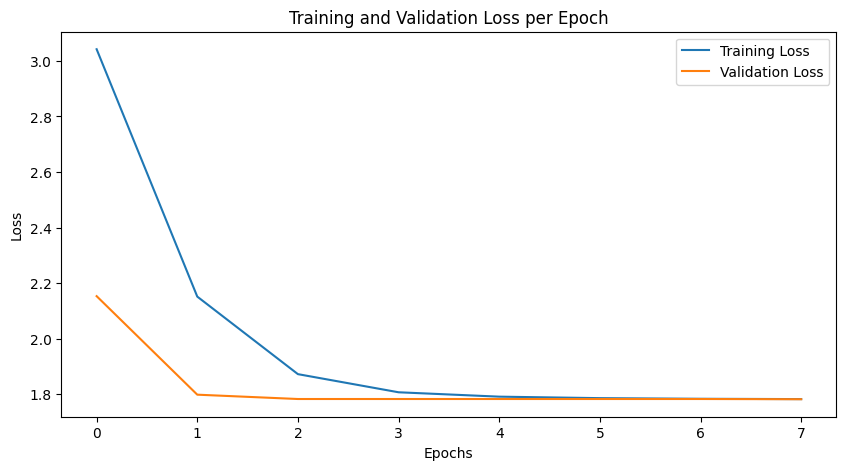

final train loss: 1.7824497275396296 
final validation loss: 1.78199771616536


In [75]:
# plotting training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(range(epochs_covered), train_losses, label='Training Loss')
plt.plot(range(epochs_covered), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.show()
print(f"final train loss: {train_losses[-1]} \nfinal validation loss: {val_losses[-1]}")

In [76]:
def evaluate(dataloader, model):
    # set model to evaluation mode
    model.eval()  
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # print(outputs, targets)
            
            # look into using a different loss function
            loss = nn.MSELoss()(outputs, targets)
            total_loss += loss.item()
            num_batches += 1

    average_loss = total_loss / num_batches
    return average_loss
accuracy = evaluate(test_loader, model)
print(f'Average Loss on test set: {accuracy:.2f}')

Average Loss on test set: 1.78


#### 6. Model Saving and Loading

In [77]:
# names the model and saves to saved_model folder
filename = '07-31-2024.pth'
current_path = os.getcwd() + "/saved_model/"
path = os.path.join(current_path, filename)
torch.save(model.state_dict(), path)

In [78]:
# you CANNOT load using 
# model.load_state_dict(PATH)
dict_obj = torch.load(path)
loaded_model = model.load_state_dict(dict_obj)
loaded_model

<All keys matched successfully>

***

### DiffLogic specific methods. 

You may safely ignore the cells below if testing a different architecture.

#### Interpretability

##### All Operations

In [79]:
ALL_OPERATIONS = [
    "zero",
    "and",
    "not_implies",
    "a",
    "not_implied_by",
    "b",
    "xor",
    "or",
    "not_or",
    "not_xor",
    "not_b",
    "implied_by",
    "not_a",
    "implies",
    "not_and",
    "one",
]

LOGIC_OPERATIONS = [
    "0", 
    "A and B", 
    "not(A implies B)", 
    "A", 
    "not(B implies A)", 
    "B",
    "A xor B", 
    "A or B", 
    "not(A or B)", 
    "not(A xor B)", 
    "not(B)", 
    "B implies A",
    "not(A)", 
    "A implies B", 
    "not(A and B)", 
    "1"
]

LOGIC_OPERATIONS_TO_GRAPH = [
    "0", 
    "A∧B", 
    "¬(A⇒B)", 
    "A", 
    "¬(B⇒A)", 
    "B",
    "A⊕B", 
    "A∨B", 
    "¬(A∨B)", 
    "¬(A⊕B)", 
    "¬B", 
    "B⇒A",
    "¬A", 
    "A⇒B", 
    "¬(A∧B)", 
    "1"
]

##### Node's Learned State

In [80]:
# lists all of the model's layers
model.logic_layers

Sequential(
  (0): LogicLayer(60, 30, eval)
)

In [81]:
# gets a specific layer from the ones listed above
model.logic_layers[0]

LogicLayer(60, 30, eval)

In [82]:
# gets all the weights for the selected layer in your model
model.logic_layers[0].weights

Parameter containing:
tensor([[-4.4956,  0.2877, -2.6728, -0.3909, -5.0867, -2.5894, -5.8269, -5.0196,
         -3.8371,  7.4735, -4.5386, -1.6521, -4.4764, -2.5274, -3.6322, -7.2663],
        [-5.1143, -2.7743, -4.9552, -5.8944, -2.7419,  7.7941, -3.8791, -0.4400,
         -5.1001, -4.0948, -1.9466, -5.8928, -2.8503, -0.2850, -5.7922, -3.4404],
        [-4.6951, -0.0314, -4.0696, -4.7933, -6.2601, -3.4624, -3.1739, -3.9918,
         -4.0442,  7.7632, -2.7065, -1.6447, -5.8053, -1.5613, -4.0453, -2.7067],
        [-3.3497, -4.6944, -5.0676, -3.5179, -6.8831, -4.9176, -4.9071, -2.6019,
         -4.7911, -2.9361, -4.6584, -1.6134, -6.2605, -1.2368, -2.5469,  7.4292],
        [-5.6052, -4.3677, -4.0738,  7.6673, -4.3024, -2.7322, -4.4611, -1.6992,
         -3.7174, -3.4118, -3.8858,  0.0752, -3.8921, -4.3456, -4.7492, -4.5606],
        [-5.0834, -0.5245, -4.6954, -2.0423, -3.3954, -5.2146, -2.8499, -4.6283,
         -5.2640,  7.7216, -3.8356, -1.9317, -5.1888, -2.4782, -5.3919, -6.4302],


In [83]:
# M x 16 tensor where M denotes the number of nodes and 16 represents each of the logic gates (AND, OR, ...)
model.logic_layers[0].weights.size()

torch.Size([30, 16])

In [84]:
model.logic_layers[0].weights.size()[0]

30

In [85]:
# Accessing a specific node's learned state.
layer_index = 0
node_index = 7

In [86]:
# gets the weights for the first node of the first logic layer
# note that the weights represent a probability distribution after applying softmax during training
# hence the highest weight corresponds to the chosen logic gate
weights = model.logic_layers[layer_index].weights[node_index]

# gets the index of the highest weight
gate_index = torch.argmax(weights).item()  

#selected_gate = ALL_OPERATIONS[gate_index] -- from the difflogic code
selected_gate = LOGIC_OPERATIONS[gate_index] # more legible

print(f"The logic gate used by neuron {node_index} is: {selected_gate}")

The logic gate used by neuron 7 is: not(A xor B)


##### Graphical Representation

In [87]:
# https://pyvis.readthedocs.io/en/latest/tutorial.html
# !pip install networkx matplotlib
# !pip install pyvis
# !pip install pyinstaller
from pyvis.network import Network
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [88]:
# these denote which PAIR of numbers are passed into each layer's node
model.logic_layers[layer_index].indices

(tensor([ 3, 14, 27, 38, 43,  7, 36, 21, 16, 58, 33, 30, 44,  6, 41, 59, 37, 42,
         13,  0, 32,  5,  1, 10, 47, 54,  2, 53,  8, 17], device='cuda:0'),
 tensor([39, 40, 34, 26, 49, 23,  4, 52, 56, 28, 12, 35, 57, 24, 50, 46, 22, 48,
         55, 11, 20, 25, 15, 29, 19,  9, 51, 45, 18, 31], device='cuda:0'))

e.g. for a 60x30 
(tensor([54,  2, 30, 10, 41, 58, 19, 11,  7,  5, 32,  9, 15,  1, 51, 57, 18, 49,
         39, 26, 21, 22, 36, 27, 33,  8, 55, 14, 13, 47], device='cuda:0'),
 tensor([45, 52,  6, 59, 35, 28, 25,  4, 46, 29,  3, 24, 38, 42, 20, 23, 37, 43,
         50, 56, 44, 48, 12, 34, 17, 53, 16,  0, 40, 31], device='cuda:0'))`

If we take the first number in each layer as an example:

54 \
    logic_gate(54, 45) -> output node
45 /

This explains why the length of each of the two tensors is 30 (the size of the output layer)

In [89]:
# Select a layer to visualize
layer_index = 0
logic_layer = model.logic_layers[layer_index]

# Create a directed graph
G = nx.DiGraph()

# Retrieve the connections 
input_indices = logic_layer.indices[0]  # Indices of the first inputs for each logic gate
output_indices = logic_layer.indices[1]  # Indices of the second inputs for each logic gate

# Iterate through each output neuron to get its input connections and determine the logic gate
for output_neuron in range(logic_layer.weights.size()[0]):
    a_idx = input_indices[output_neuron].item()  # Index of the first input neuron
    b_idx = output_indices[output_neuron].item()  # Index of the second input neuron
    gate_idx = torch.argmax(logic_layer.weights[output_neuron]).item()  # Most probable gate index
    gate_label = LOGIC_OPERATIONS_TO_GRAPH[gate_idx]  # Get the label of the gate

    # Add nodes and edges to the graph
    G.add_node(a_idx, label=f"Node {a_idx}")
    G.add_node(b_idx, label=f"Node {b_idx}")
    G.add_node(output_neuron, label=f"{gate_label}")
    G.add_edge(a_idx, output_neuron, label=gate_label)
    G.add_edge(b_idx, output_neuron, label=gate_label)

# Create a PyVis network from the NetworkX graph
nt = Network("500px", "1000px", notebook=True)
nt.from_nx(G)
nt.show_buttons(filter_=['physics'])  # This allows you to interactively adjust the physics of the network

# Save and display the interactive graph
nt.show("network.html")

network.html


In [90]:
#get_learned_logic_gate(model, 1, 1) #-- no attributes layers
model.state_dict()

OrderedDict([('logic_layers.0.weights',
              tensor([[-4.4956,  0.2877, -2.6728, -0.3909, -5.0867, -2.5894, -5.8269, -5.0196,
                       -3.8371,  7.4735, -4.5386, -1.6521, -4.4764, -2.5274, -3.6322, -7.2663],
                      [-5.1143, -2.7743, -4.9552, -5.8944, -2.7419,  7.7941, -3.8791, -0.4400,
                       -5.1001, -4.0948, -1.9466, -5.8928, -2.8503, -0.2850, -5.7922, -3.4404],
                      [-4.6951, -0.0314, -4.0696, -4.7933, -6.2601, -3.4624, -3.1739, -3.9918,
                       -4.0442,  7.7632, -2.7065, -1.6447, -5.8053, -1.5613, -4.0453, -2.7067],
                      [-3.3497, -4.6944, -5.0676, -3.5179, -6.8831, -4.9176, -4.9071, -2.6019,
                       -4.7911, -2.9361, -4.6584, -1.6134, -6.2605, -1.2368, -2.5469,  7.4292],
                      [-5.6052, -4.3677, -4.0738,  7.6673, -4.3024, -2.7322, -4.4611, -1.6992,
                       -3.7174, -3.4118, -3.8858,  0.0752, -3.8921, -4.3456, -4.7492, -4.5606],
     

#### DiffLogic -> Logic Network

In [91]:
def zero(a, b):
    return np.zeros_like(a)

def logical_and(a, b):
    return np.logical_and(a, b)

def not_implies(a, b):
    return np.logical_and(a, np.logical_not(b))

def identity_a(a, b):
    return a

def not_implied_by(a, b):
    return np.logical_and(b, np.logical_not(a))

def identity_b(a, b):
    return b

def logical_xor(a, b):
    return np.logical_xor(a, b)

def logical_or(a, b):
    return np.logical_or(a, b)

def not_or(a, b):
    return np.logical_not(np.logical_or(a, b))

def not_xor(a, b):
    return np.logical_not(np.logical_xor(a, b))

def not_b(a, b):
    return np.logical_not(b)

def implied_by(a, b):
    return np.logical_or(np.logical_not(b), a)

def not_a(a, b):
    return np.logical_not(a)

def implies(a, b):
    return np.logical_or(np.logical_not(a), b)

def not_and(a, b):
    return np.logical_not(np.logical_and(a, b))

def one(a, b):
    return np.ones_like(a)

logic_gates = [zero, logical_and, not_implies, identity_a, not_implied_by, identity_b,
               logical_xor, logical_or, not_or, not_xor, not_b, implied_by, not_a,
               implies, not_and, one]

In [92]:
import torch
import numpy as np

layer_index = 0
logic_layer = model.logic_layers[layer_index]

neuron_gates = []
connections = {}

input_indices = logic_layer.indices[0].cpu().numpy()  # First input indices
output_indices = logic_layer.indices[1].cpu().numpy()  # Second input indices

for output_neuron in range(logic_layer.weights.size()[0]):
    gate_idx = torch.argmax(logic_layer.weights[output_neuron]).item()
    neuron_gates.append(gate_idx)
    connections[output_neuron] = (input_indices[output_neuron], output_indices[output_neuron])

In [68]:
# forward using DiffLogic and eval using LogicNetwork
class LogicNeuron:
    def __init__(self, gate_idx):
        self.operation = logic_gates[gate_idx]

    def forward(self, input_a, input_b):
        return self.operation(input_a, input_b)

class LogicNetwork:
    def __init__(self, neuron_gates, connections):
        self.neurons = {i: LogicNeuron(gate) for i, gate in enumerate(neuron_gates)}
        self.connections = connections

    def forward(self, inputs):
        outputs = {}
        for neuron_id in self.connections:
            input_a_idx, input_b_idx = self.connections[neuron_id]
            input_a = inputs[input_a_idx]
            input_b = inputs[input_b_idx]
            outputs[neuron_id] = self.neurons[neuron_id].forward(input_a, input_b)
        return outputs

In [69]:
# Example input, currently just random numbers.
inputs = np.random.choice([True, False], size=(max(input_indices.max(), output_indices.max()) + 1))

# Initialize the network
network = LogicNetwork(neuron_gates, connections)

# Execute the network
outputs = network.forward(inputs)
print(outputs)

{0: True, 1: True, 2: True, 3: True, 4: True, 5: True, 6: False, 7: True, 8: False, 9: array(True), 10: array(True), 11: False, 12: True, 13: False, 14: array(True), 15: True, 16: True, 17: True, 18: False, 19: True, 20: True, 21: True, 22: False, 23: False, 24: True, 25: array(True), 26: True, 27: True, 28: True, 29: True, 30: True, 31: True, 32: True, 33: array(True), 34: True, 35: True, 36: True, 37: True, 38: True, 39: False, 40: True, 41: False, 42: True, 43: False, 44: array(True), 45: True, 46: False, 47: False, 48: False, 49: array(True), 50: True, 51: array(True), 52: array(True), 53: True, 54: True, 55: True, 56: True, 57: True, 58: False, 59: True}


#### Verilog File Creation

In [70]:
import torch
import numpy as np

# Logic gate to Verilog expression mapping
logic_gate_verilog = {
    "0": "1'b0",
    "A∧B": "{a} & {b}",
    "¬(A⇒B)": "{a} & ~{b}",
    "A": "{a}",
    "¬(B⇒A)": "{b} & ~{a}",
    "B": "{b}",
    "A⊕B": "{a} ^ {b}",
    "A∨B": "{a} | {b}",
    "¬(A∨B)": "~({a} | {b})",
    "¬(A⊕B)": "~({a} ^ {b})",
    "¬B": "~{b}",
    "B⇒A": "~{b} | {a}",
    "¬A": "~{a}",
    "A⇒B": "~{a} | {b}",
    "¬(A∧B)": "~({a} & {b})",
    "1": "1'b1"
}

# Assuming `model` and `logic_layer` have already been defined and populated
layer_index = 0
logic_layer = model.logic_layers[layer_index]

input_indices = logic_layer.indices[0].cpu().numpy()  # First input indices
output_indices = logic_layer.indices[1].cpu().numpy()  # Second input indices
neuron_gates = [torch.argmax(logic_layer.weights[neuron]).item() for neuron in range(logic_layer.weights.size()[0])]
connections = {i: (input_indices[i], output_indices[i]) for i in range(len(neuron_gates))}

def generate_verilog(neuron_gates, connections, filename="logic_network.v"):
    with open(filename, 'w') as file:
        file.write("module logic_network(\n")
        file.write("    input wire [{}:0] inputs,\n".format(max(max(connections.keys()), max(max(con) for con in connections.values()))))
        file.write("    output wire [{}:0] outputs\n".format(len(neuron_gates) - 1))
        file.write(");\n\n")

        # Declare wires for internal connections
        for neuron_id in connections:
            a_idx, b_idx = connections[neuron_id]
            gate = logic_gate_verilog[logic_operations[neuron_gates[neuron_id]]].format(a=f"inputs[{a_idx}]", b=f"inputs[{b_idx}]")
            file.write(f"    assign outputs[{neuron_id}] = {gate};\n")

        file.write("endmodule\n")

# Generate Verilog file
generate_verilog(neuron_gates, connections)

#### Verilog File Reading and Visualiazation

In [6]:
#!pip install pyverilog graphviz

In [8]:
import pyverilog.vparser.parser as parser
from graphviz import Digraph

def create_schematic_from_verilog(file_path):
    ast, _ = parser.parse([file_path])
    dot = Digraph(comment='Verilog Schematic')

    # Function to recursively visit nodes and create edges
    def visit(node, parent=None):
        if node is None:
            return
        if hasattr(node, 'name'):
            dot.node(node.name, label=str(node.__class__).split('.')[-1].strip("'>"))
            if parent:
                dot.edge(parent.name, node.name)
        
        if hasattr(node, 'children'):
            for child in node.children():
                visit(child, parent=node)

    visit(ast)
    dot.render('output/schematic', view=True)  # Saves and opens the schematic diagram

# Example usage
create_schematic_from_verilog('logic_network.v')

Generating LALR tables


FileNotFoundError: [Errno 2] No such file or directory: 'iverilog'

In [10]:
# Olivia's thought on how "strong" a certain connection is. aka why one gate was chosen over another one (based on probability, but what was second probability, etc)
# e.g. 80% AND gate, 10% NAND gate, 5% OR gate, ...
# Ensembl model
# if we changed a certain ouput, what would happen?